In [1]:
import pandas as pd
from io import StringIO

data = """State,City,PostalCode,Latitude,Longitude,Population,Users,Revenue
Odisha,Bhubaneswar,751001,20.2961,85.8245,1040000,8200,8200000
Odisha,Cuttack,753001,20.4625,85.8830,610000,5100,5100000
Odisha,Rourkela,769001,22.2604,84.8536,550000,4200,4200000
Odisha,Berhampur,760001,19.3150,84.7941,350000,2800,2800000
Jharkhand,Ranchi,834001,23.3441,85.3096,1070000,7200,7200000
Jharkhand,Jamshedpur,831001,22.8046,86.2029,680000,5400,5400000
Jharkhand,Dhanbad,826001,23.7957,86.4304,1200000,3900,3900000
Jharkhand,Bokaro,827001,23.6693,86.1511,560000,3100,3100000
West Bengal,Kolkata,700001,22.5726,88.3639,4490000,18500,18500000
West Bengal,Siliguri,734001,26.7271,88.3953,510000,3900,3900000
West Bengal,Durgapur,713201,23.5204,87.3119,580000,4300,4300000
West Bengal,Asansol,713301,23.6739,87.1510,560000,3500,3500000
Bihar,Patna,800001,25.5941,85.1376,1680000,8500,8500000
Bihar,Gaya,823001,24.7955,84.9994,470000,2600,2600000
Bihar,Muzaffarpur,842001,26.1209,85.3647,350000,2400,2400000
Bihar,Bhagalpur,812001,25.2425,86.9842,400000,2200,2200000
Chhattisgarh,Raipur,492001,21.2514,81.6296,1020000,6900,6900000
Chhattisgarh,Bhilai,490001,21.1938,81.3509,630000,4100,4100000
Chhattisgarh,Bilaspur,495001,22.0797,82.1409,365000,2100,2100000
Madhya Pradesh,Bhopal,462001,23.2599,77.4126,1800000,8200,8200000
Madhya Pradesh,Indore,452001,22.7196,75.8577,1960000,11200,11200000
Madhya Pradesh,Jabalpur,482001,23.1815,79.9864,1050000,4800,4800000
Uttar Pradesh,Lucknow,226001,26.8467,80.9462,3380000,14200,14200000
Uttar Pradesh,Kanpur,208001,26.4499,80.3319,2920000,9800,9800000
Uttar Pradesh,Varanasi,221001,25.3176,82.9739,1200000,6200,6200000
Uttar Pradesh,Prayagraj,211001,25.4358,81.8463,1110000,4500,4500000
Maharashtra,Mumbai,400001,19.0760,72.8777,12600000,32000,32000000
Maharashtra,Pune,411001,18.5204,73.8567,3120000,18500,18500000
Gujarat,Ahmedabad,380001,23.0225,72.5714,5630000,21000,21000000
Karnataka,Bengaluru,560001,12.9716,77.5946,8490000,28500,28500000"""

df = pd.read_csv(StringIO(data))

df.head()

,State,City,PostalCode,Latitude,Longitude,Population,Users,Revenue
0,Odisha,Bhubaneswar,751001,20.2961,85.8245,1040000,8200,8200000
1,Odisha,Cuttack,753001,20.4625,85.8830,610000,5100,5100000
2,Odisha,Rourkela,769001,22.2604,84.8536,550000,4200,4200000
3,Odisha,Berhampur,760001,19.3150,84.7941,350000,2800,2800000
4,Jharkhand,Ranchi,834001,23.3441,85.3096,1070000,7200,7200000


In [2]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Shape: (30, 8)

Columns:
Index(['State', 'City', 'PostalCode', 'Latitude', 'Longitude', 'Population',
       'Users', 'Revenue'],
      dtype='str')

Missing values:
State         0
City          0
PostalCode    0
Latitude      0
Longitude     0
Population    0
Users         0
Revenue       0
dtype: int64

Duplicate rows: 0

Data types:
State             str
City              str
PostalCode      int64
Latitude      float64
Longitude     float64
Population      int64
Users           int64
Revenue         int64
dtype: object


In [3]:
df = df.drop_duplicates()

df["PostalCode"] = df["PostalCode"].astype(str)

df["Revenue"] = pd.to_numeric(df["Revenue"])
df["Users"] = pd.to_numeric(df["Users"])
df["Population"] = pd.to_numeric(df["Population"])

print("Cleaning completed")
print("Shape:", df.shape)

Cleaning completed
Shape: (30, 8)


In [4]:
df["Revenue_per_User"] = df["Revenue"] / df["Users"]

df["User_Density"] = (df["Users"] / df["Population"]) * 100000

df["Revenue_per_Capita"] = df["Revenue"] / df["Population"]

df[[
    "State",
    "City",
    "Revenue",
    "Users",
    "Revenue_per_User",
    "User_Density",
    "Revenue_per_Capita"
]].head(10)

,State,City,Revenue,Users,Revenue_per_User,User_Density,Revenue_per_Capita
0,Odisha,Bhubaneswar,8200000,8200,1000.0,788.461538,7.884615
1,Odisha,Cuttack,5100000,5100,1000.0,836.065574,8.360656
2,Odisha,Rourkela,4200000,4200,1000.0,763.636364,7.636364
3,Odisha,Berhampur,2800000,2800,1000.0,800.000000,8.000000
4,Jharkhand,Ranchi,7200000,7200,1000.0,672.897196,6.728972
5,Jharkhand,Jamshedpur,5400000,5400,1000.0,794.117647,7.941176
6,Jharkhand,Dhanbad,3900000,3900,1000.0,325.000000,3.250000
7,Jharkhand,Bokaro,3100000,3100,1000.0,553.571429,5.535714
8,West Bengal,Kolkata,18500000,18500,1000.0,412.026726,4.120267
9,West Bengal,Siliguri,3900000,3900,1000.0,764.705882,7.647059


In [5]:
state_summary = df.groupby("State").agg(
    Total_Revenue=("Revenue", "sum"),
    Total_Users=("Users", "sum"),
    Total_Population=("Population", "sum")
).reset_index()

state_summary["Revenue_per_User"] = (
    state_summary["Total_Revenue"] /
    state_summary["Total_Users"]
)

state_summary["User_Density"] = (
    state_summary["Total_Users"] /
    state_summary["Total_Population"]
) * 100000

state_summary.sort_values(
    "Total_Revenue",
    ascending=False
)

,State,Total_Revenue,Total_Users,Total_Population,Revenue_per_User,User_Density
6,Maharashtra,50500000,50500,15720000,1000.0,321.246819
8,Uttar Pradesh,34700000,34700,8610000,1000.0,403.019744
9,West Bengal,30200000,30200,6140000,1000.0,491.856678
4,Karnataka,28500000,28500,8490000,1000.0,335.689046
5,Madhya Pradesh,24200000,24200,4810000,1000.0,503.118503
2,Gujarat,21000000,21000,5630000,1000.0,373.001776
7,Odisha,20300000,20300,2550000,1000.0,796.078431
3,Jharkhand,19600000,19600,3510000,1000.0,558.404558
0,Bihar,15700000,15700,2900000,1000.0,541.379310
1,Chhattisgarh,13100000,13100,2015000,1000.0,650.124069


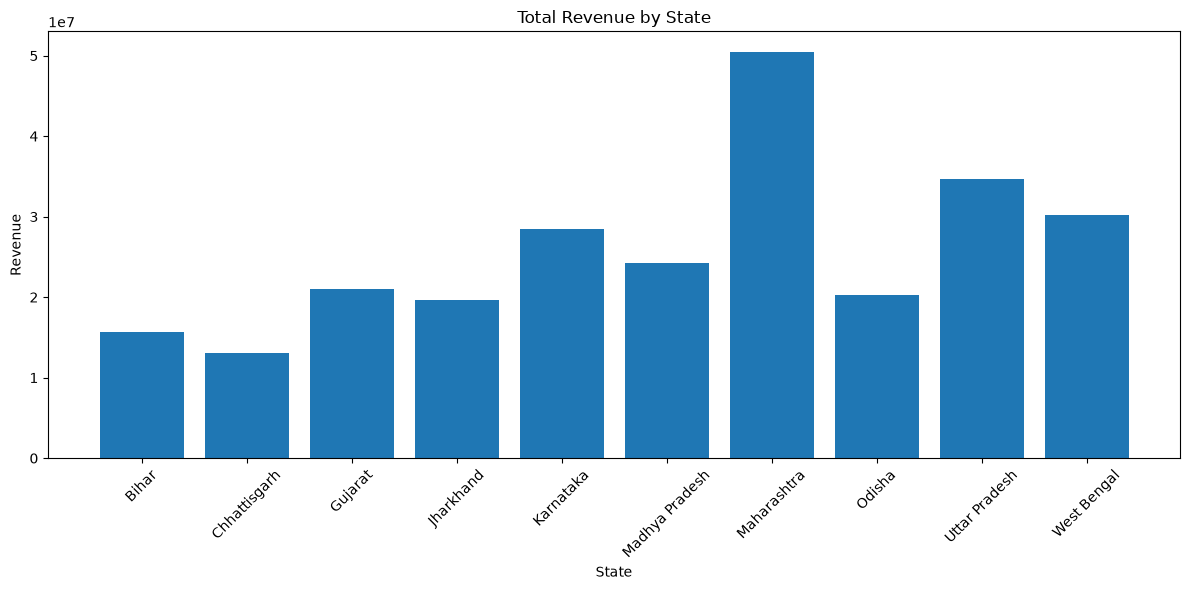

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    state_summary["State"],
    state_summary["Total_Revenue"]
)

plt.title("Total Revenue by State")
plt.xlabel("State")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

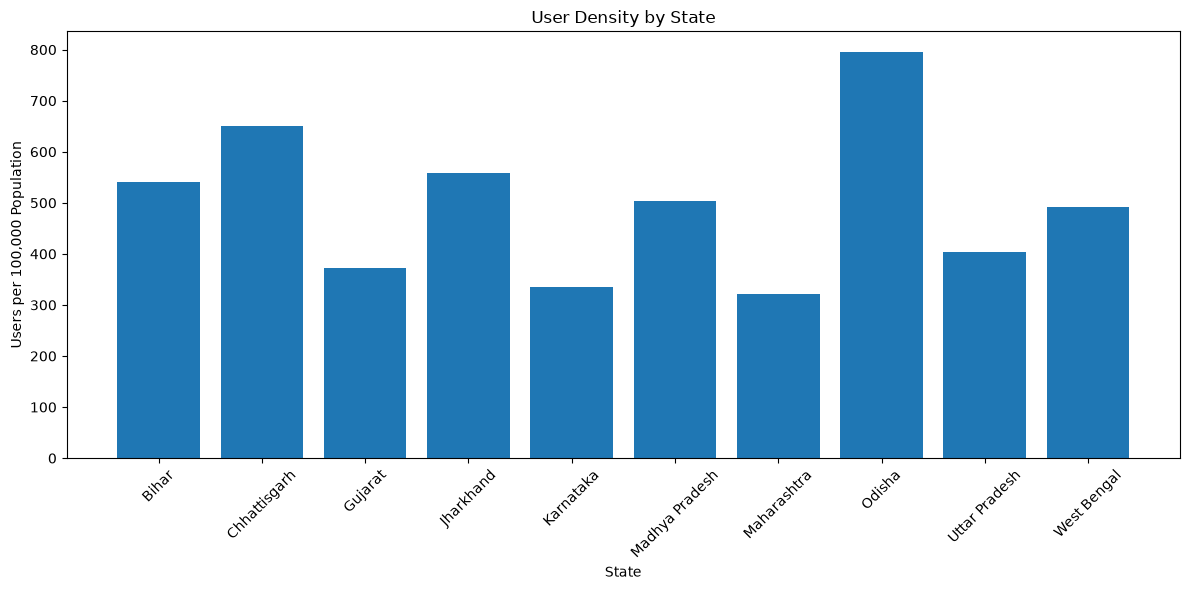

In [7]:
plt.figure(figsize=(12, 6))

plt.bar(
    state_summary["State"],
    state_summary["User_Density"]
)

plt.title("User Density by State")
plt.xlabel("State")
plt.ylabel("Users per 100,000 Population")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [8]:
df["User_Penetration"] = (df["Users"] / df["Population"]) * 100

population_median = df["Population"].median()
penetration_median = df["User_Penetration"].median()

df["OpportunityScore"] = (
    (df["Population"] / population_median) /
    (df["User_Penetration"] / penetration_median)
)

opportunities = df[
    (df["Population"] >= population_median) &
    (df["User_Penetration"] <= penetration_median)
].sort_values(
    "OpportunityScore",
    ascending=False
)

print(
    opportunities[
        [
            "State",
            "City",
            "Population",
            "Users",
            "User_Penetration",
            "Revenue",
            "OpportunityScore"
        ]
    ].head(3)
)

          State       City  Population  Users  User_Penetration   Revenue  \
26  Maharashtra     Mumbai    12600000  32000          0.253968  32000000   
29    Karnataka  Bengaluru     8490000  28500          0.335689  28500000   
28      Gujarat  Ahmedabad     5630000  21000          0.373002  21000000   

    OpportunityScore  
26         26.705293  
29         13.613718  
28          8.124633  


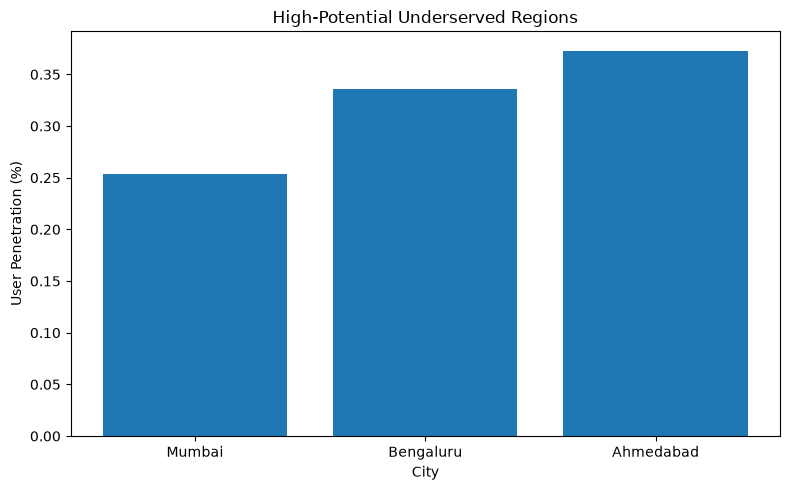

In [9]:
top_regions = opportunities.head(3)

plt.figure(figsize=(8, 5))

plt.bar(
    top_regions["City"],
    top_regions["User_Penetration"]
)

plt.title("High-Potential Underserved Regions")
plt.xlabel("City")
plt.ylabel("User Penetration (%)")

plt.tight_layout()
plt.show()

In [10]:
!pip install folium


   ---------------------------------------- 0/2 [branca]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   ---------------------------------------- 2/2 [folium]



In [11]:
import folium

m = folium.Map(
    location=[22.5, 82.5],
    zoom_start=5
)

for _, row in df.iterrows():

    popup = f"""
    <b>{row['City']}, {row['State']}</b><br>
    Revenue: ₹{row['Revenue']:,.0f}<br>
    Users: {row['Users']:,}<br>
    Population: {row['Population']:,}<br>
    User Penetration: {row['User_Penetration']:.2f}%<br>
    Revenue per User: ₹{row['Revenue_per_User']:,.2f}
    """

    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=8,
        popup=folium.Popup(popup, max_width=300),
        tooltip=row["City"],
        fill=True
    ).add_to(m)

m

In [12]:
m.save("geospatial_analysis_map.html")

In [13]:
top_cities = opportunities.head(3)["City"].tolist()

for _, row in df.iterrows():

    if row["City"] in top_cities:
        color = "red"
        radius = 14
    else:
        color = "blue"
        radius = 7

    popup = f"""
    <b>{row['City']}, {row['State']}</b><br>
    Revenue: ₹{row['Revenue']:,.0f}<br>
    Users: {row['Users']:,}<br>
    Population: {row['Population']:,}<br>
    User Penetration: {row['User_Penetration']:.2f}%<br>
    Opportunity Score: {row['OpportunityScore']:.2f}
    """

    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=radius,
        color=color,
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(popup, max_width=300),
        tooltip=row["City"]
    ).add_to(m)

m

In [14]:
m.save("geospatial_analysis_map.html")

In [15]:
final_summary = opportunities.head(3)[
    [
        "State",
        "City",
        "Population",
        "Users",
        "User_Penetration",
        "Revenue",
        "OpportunityScore"
    ]
].copy()

final_summary

,State,City,Population,Users,User_Penetration,Revenue,OpportunityScore
26,Maharashtra,Mumbai,12600000,32000,0.253968,32000000,26.705293
29,Karnataka,Bengaluru,8490000,28500,0.335689,28500000,13.613718
28,Gujarat,Ahmedabad,5630000,21000,0.373002,21000000,8.124633


In [16]:
state_summary.sort_values(
    "Total_Revenue",
    ascending=False
)

,State,Total_Revenue,Total_Users,Total_Population,Revenue_per_User,User_Density
6,Maharashtra,50500000,50500,15720000,1000.0,321.246819
8,Uttar Pradesh,34700000,34700,8610000,1000.0,403.019744
9,West Bengal,30200000,30200,6140000,1000.0,491.856678
4,Karnataka,28500000,28500,8490000,1000.0,335.689046
5,Madhya Pradesh,24200000,24200,4810000,1000.0,503.118503
2,Gujarat,21000000,21000,5630000,1000.0,373.001776
7,Odisha,20300000,20300,2550000,1000.0,796.078431
3,Jharkhand,19600000,19600,3510000,1000.0,558.404558
0,Bihar,15700000,15700,2900000,1000.0,541.379310
1,Chhattisgarh,13100000,13100,2015000,1000.0,650.124069


In [17]:
top_city = opportunities.iloc[0]

print("TOP OPPORTUNITY REGION")
print(f"City: {top_city['City']}")
print(f"State: {top_city['State']}")
print(f"Population: {top_city['Population']:,}")
print(f"Users: {top_city['Users']:,}")
print(f"User Penetration: {top_city['User_Penetration']:.2f}%")
print(f"Revenue: ₹{top_city['Revenue']:,.0f}")
print(f"Opportunity Score: {top_city['OpportunityScore']:.2f}")

TOP OPPORTUNITY REGION
City: Mumbai
State: Maharashtra
Population: 12,600,000
Users: 32,000
User Penetration: 0.25%
Revenue: ₹32,000,000
Opportunity Score: 26.71


In [18]:
print("KEY FINDINGS")
print("-" * 40)

print("1. Revenue varies substantially across the analyzed cities.")
print("2. Large population with relatively low user penetration indicates potential expansion opportunities.")
print("3. The interactive map highlights geographic differences in users and revenue.")
print("4. The top opportunity regions can be prioritized for further market analysis.")
print("5. Results are based on the self-created representative dataset.")

KEY FINDINGS
----------------------------------------
1. Revenue varies substantially across the analyzed cities.
2. Large population with relatively low user penetration indicates potential expansion opportunities.
3. The interactive map highlights geographic differences in users and revenue.
4. The top opportunity regions can be prioritized for further market analysis.
5. Results are based on the self-created representative dataset.
